# Exploração de Dados: Manutenção Preventiva com N-CMAPSS

Este notebook tem como objetivo explorar o dataset sintético **N-CMAPSS** da NASA, utilizado para prever a vida útil restante (RUL - Remaining Useful Life) de motores do tipo Turbofan (aviões). 

## 1. Dicionário de Dados
Entendendo as variáveis presentes no dataset. Os dados fornecidos pelo simulador contêm as condições de voo, os sensores internos do motor e a variável alvo.

### A - Variáveis Auxiliares (Identificação)
- **`unit`**: ID único do motor / unidade (Numérica / Float ou Inteiro)
- **`cycle`**: Número do ciclo de voo atual (Numérica / Float ou Inteiro)
- **`Fc`**: Classe de voo (Numérica / Categórica)
- **`hs`**: Estado de saúde do motor - *Health State* (Numérica / Float)

### W - Condições de Voo (Flight Conditions)
Estas variáveis descrevem o ambiente e o comando do piloto, que afetam o funcionamento do motor:
- **`alt`**: Altitude do voo em pés [ft] (Numérica / Float)
- **`Mach`**: Número de Mach - velocidade (Numérica / Float)
- **`TRA`**: *Throttle Resolver Angle* - ângulo do acelerador em % (Numérica / Float)
- **`T2`**: Temperatura na entrada do Fan em °R (Numérica / Float)

### X_s - Sensores Físicos (Physical Sensors)
São os 14 sensores reais espalhados pelas peças do motor (Compressores, Turbinas). Eles medem a temperatura e pressão, e a alteração no padrão deles indica que as peças estão se desgastando:
- **`T24`, `T30`, `T48`, `T50`**: Temperaturas em diferentes estágios do motor (Numérica / Float)
- **`P15`, `P2`, `P21`, `P24`, `Ps30`, `P40`, `P50`**: Pressões em diferentes estágios do motor (Numérica / Float)
- **`Nf`, `Nc`**: Velocidades físicas dos rotores (Numérica / Float)
- **`Wf`**: Fluxo de combustível (Numérica / Float)

### Y - Variável Alvo (Target)
- **`RUL`**: *Remaining Useful Life* - Ciclos restantes até a falha catastrófica do motor (Numérica / Inteiro ou Float)

## 2. Carregamento dos Dados
Abaixo, acessamos o arquivo HDF5 (`DS02`) e consolidamos todas as variáveis em um único **DataFrame** unificado para facilitar as análises

In [11]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

filename = 'data/N-CMAPSS_DS02-006.h5'

try:
    with h5py.File(filename, 'r') as hdf:
        # Extraindo dados de desenvolvimento/treino
        W_dev = np.array(hdf.get('W_dev'))             
        X_s_dev = np.array(hdf.get('X_s_dev'))         
        Y_dev = np.array(hdf.get('Y_dev'))             
        A_dev = np.array(hdf.get('A_dev')) 
        
        # Extraindo os nomes das variáveis (transformando de bytes para string)
        W_var = ['alt', 'Mach', 'TRA', 'T2']
        X_s_var = ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf']
        A_var = ['unit', 'cycle', 'Fc', 'hs']
        
    # Criando DataFrames individuais
    df_A = pd.DataFrame(A_dev, columns=A_var)
    df_W = pd.DataFrame(W_dev, columns=W_var)
    df_Xs = pd.DataFrame(X_s_dev, columns=X_s_var)
    df_Y = pd.DataFrame(Y_dev, columns=['RUL'])

    # Unindo tudo em um ÚNICO DataFrame
    df_completo = pd.concat([df_A, df_W, df_Xs, df_Y], axis=1)

    print("Dados carregados e unificados com sucesso")
    print(f"Dimensão do DataFrame Completo: {df_completo.shape}")
    display(df_completo.head())
    
except Exception as e:
    print("Erro ao carregar o arquivo. Verifique se o dataset foi baixado e salvo na pasta 'data/'.", e)

Dados carregados e unificados com sucesso
Dimensão do DataFrame Completo: (5263447, 23)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,P2,P21,P24,Ps30,P40,P50,Nf,Nc,Wf,RUL
0,2.0,1.0,3.0,1.0,10005.0,0.448497,76.903748,502.420918,600.148034,1438.498187,...,11.577097,16.046971,20.126624,331.293679,336.631827,12.629361,2160.926416,8591.373490,3.855337,74
1,2.0,1.0,3.0,1.0,10013.0,0.447741,76.903748,502.326114,600.055894,1438.350208,...,11.568235,16.036017,20.113218,331.109867,336.446748,12.623033,2160.909333,8590.972866,3.852319,74
2,2.0,1.0,3.0,1.0,10017.0,0.448938,77.079529,502.416067,600.210756,1439.109101,...,11.574866,16.048474,20.130956,331.753181,337.082502,12.637951,2161.819062,8593.031745,3.866201,74
3,2.0,1.0,3.0,1.0,10024.0,0.449883,77.079529,502.469893,600.369717,1439.240230,...,11.578198,16.057218,20.146716,331.819136,337.162828,12.631509,2162.768666,8593.781545,3.863328,74
4,2.0,1.0,3.0,1.0,10031.0,0.449379,77.079529,502.401271,600.298227,1439.064004,...,11.571593,16.048236,20.135888,331.626003,336.966936,12.624872,2162.619544,8593.220200,3.860818,74


## 3. Análise Exploratória (EDA)
Com o DataFrame unificado, podemos explorar facilmente como o RUL decai e como os sensores se comportam.

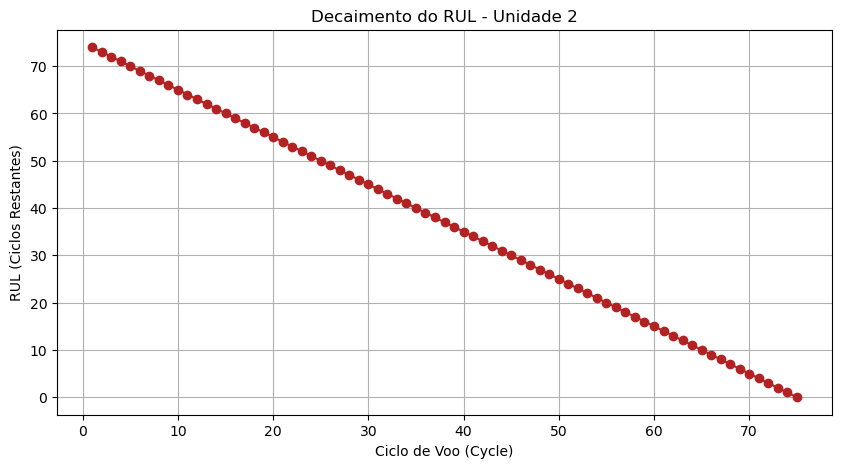

In [3]:
try:
    # Decaimento do RUL para a Unidade 2
    df_unit_2 = df_completo[df_completo['unit'] == 2.0]
    
    # Pegando apenas 1 ponto por ciclo (já que cada ciclo tem várias medições por segundo)
    df_rul = df_unit_2.drop_duplicates(subset=['cycle'])

    plt.figure(figsize=(10, 5))
    plt.plot(df_rul['cycle'], df_rul['RUL'], marker='o', linestyle='-', color='firebrick')
    plt.title('Decaimento do RUL - Unidade 2')
    plt.xlabel('Ciclo de Voo (Cycle)')
    plt.ylabel('RUL (Ciclos Restantes)')
    plt.grid(True)
    plt.show()
except NameError:
    pass

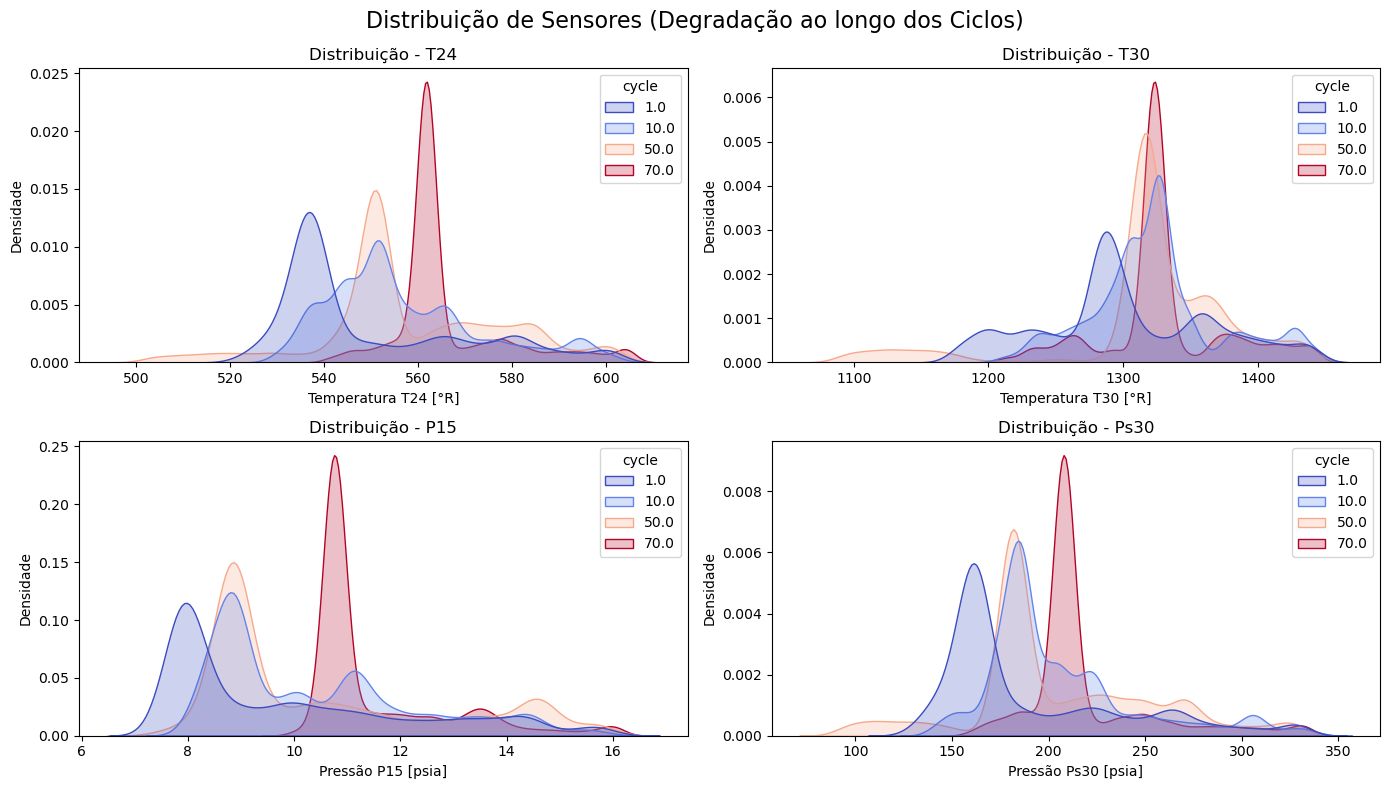

In [4]:
try:
    # Distribuição dos sensores em ciclos iniciais vs ciclos finais
    sensores_chave = ['T24', 'T30', 'P15', 'Ps30'] 
    df_xs_plot = df_completo[(df_completo['unit'] == 2.0) & (df_completo['cycle'].isin([1, 10, 50, 70]))].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Distribuição de Sensores (Degradação ao longo dos Ciclos)', fontsize=16)

    for i, sensor in enumerate(sensores_chave):
        ax = axes[i//2, i%2]
        sns.kdeplot(data=df_xs_plot, x=sensor, hue='cycle', ax=ax, fill=True, palette='coolwarm')
        ax.set_title(f'Distribuição - {sensor}')
        
        # Ajustando os nomes dos eixos conforme a física do sensor
        if sensor.startswith('T'):
            ax.set_xlabel(f'Temperatura {sensor} [°R]')
        elif sensor.startswith('P'):
            ax.set_xlabel(f'Pressão {sensor} [psia]')
        else:
            ax.set_xlabel(sensor)
            
        ax.set_ylabel('Densidade')

    plt.tight_layout()
    plt.show()

except NameError:
    pass

## 4. Análises para o Artigo Científico

Configurando gráficos para o padrão **IEEE** (tamanhos e resoluções adequadas para publicação em duas colunas).

In [5]:
try:
    plt.rcParams.update({
        'font.family': 'serif',
        'axes.labelsize': 10,
        'font.size': 10,
        'legend.fontsize': 8,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'figure.figsize': (3.5, 2.5),  # Tamanho padrão para coluna única IEEE
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight'
    })
except:
    pass

### 4.1. Matriz de Correlação Cruzada (Sensors vs RUL)
- **O que é:** Um Heatmap mostrando a correlação linear de Pearson entre todos os 14 sensores físicos e a variável alvo (RUL).
- **Motivação:** Escolher e provar quais sensores capturam a degradação e quais são irrelevantes.
- **Impacto no Artigo:** Justifica a etapa de Seleção de Features (*Feature Engineering*). Mostra cientificamente que a degradação não atinge o motor de forma homogênea, validando a escolha das features que alimentarão a MLP.

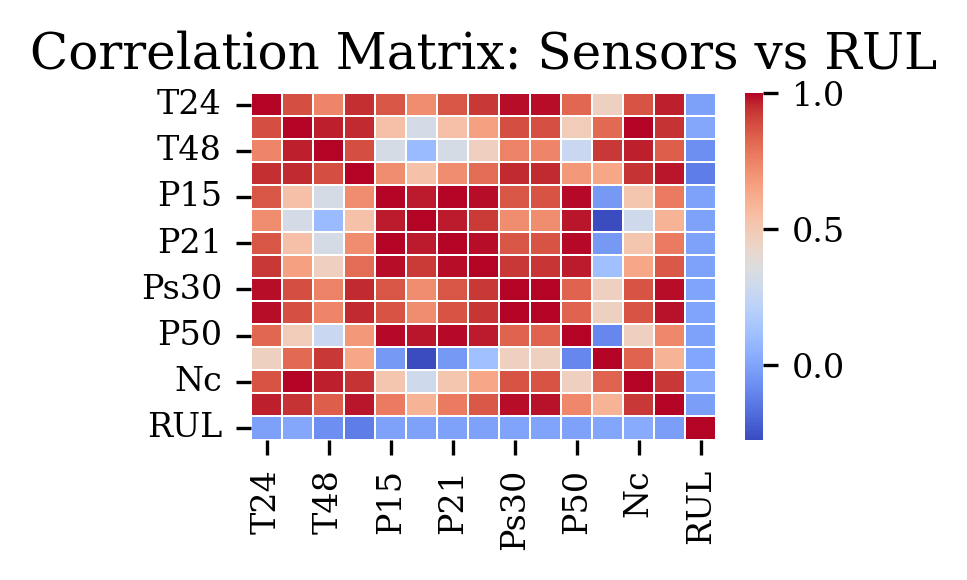

In [13]:
try:
    # Pegando amostra de sensores + alvo
    # Lista dos sensores físicos (ajuste conforme a real quantidade do seu hdf5)
    sensores = list(X_s_var)
    cols_to_corr = sensores + ['RUL']
    df_corr = df_completo[cols_to_corr].corr()

    plt.figure(figsize=(2.5, 1.5)) # Um pouco maior para caber a matriz
    sns.heatmap(df_corr, cmap='coolwarm', cbar=True, annot=False, linewidths=0.01)
    plt.title('Correlation Matrix: Sensors vs RUL')
    plt.show()
except NameError:
    pass

### 4.2. Separação de Estados (Clusters Saudáveis vs Degradados via PCA)
- **O que é:** Redução de dimensionalidade dos 14 sensores para apenas 2 componentes principais (PCA).
- **Motivação:** Visualizar se o desgaste do motor é matematicamente separável em estágios de vida.
- **Impacto no Artigo:** Prova para o leitor que os dados contêm um sinal forte e claro de degradação. Motores nos ciclos iniciais formarão um cluster diferente dos motores prestes a falhar, endossando a capacidade preditiva dos dados independentemente do modelo escolhido.

Árvores, Regressão(Ridge e Lasso), 

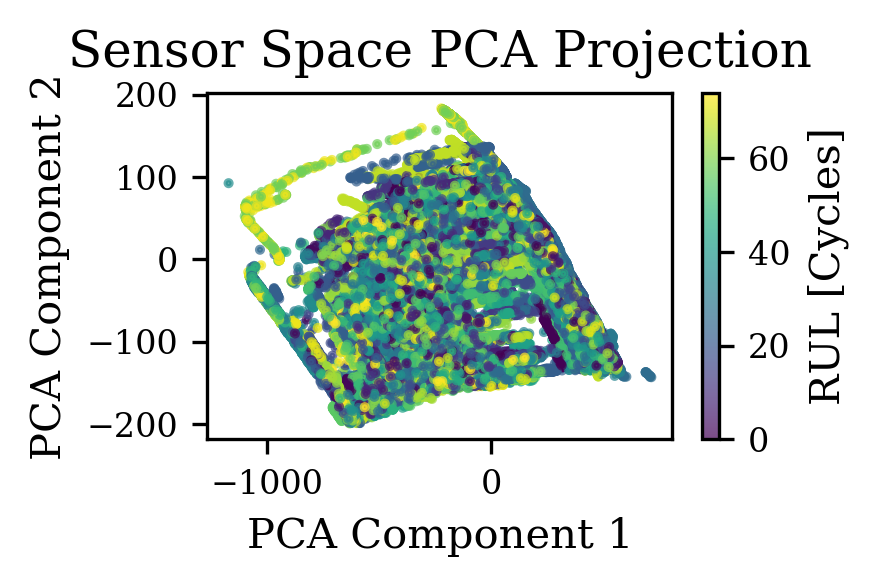

In [7]:
from sklearn.decomposition import PCA

try:
    # Selecionar uma amostra para o PCA rodar rápido e não poluir o gráfico
    df_pca_sample = df_completo[df_completo['unit'] <= 3.0].sample(frac=0.2, random_state=42)
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(df_pca_sample[sensores])
    
    plt.figure(figsize=(2.5, 1.5))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                          c=df_pca_sample['RUL'], cmap='viridis', s=2, alpha=0.7)
    cbar = plt.colorbar(scatter)
    cbar.set_label('RUL [Cycles]')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title('Sensor Space PCA Projection')
    plt.show()
except NameError:
    pass

### 4.3. O Impacto Direto do Voo no Sensor (Isolamento de Ruído)
- **O que é:** Plot das condições de voo versus a leitura de um sensor no mesmo eixo de tempo.
- **Motivação:** Demonstrar o alto nível de ruído provocado pelas manobras do avião.
- **Impacto no Artigo:** Esse é o grande diferencial do dataset N-CMAPSS (Flight Conditions Reais). Argumenta perfeitamente por que modelos clássicos de manutenção (como regressão linear simples ou limiares fixos) falhariam aqui. É a prova de que precisamos de uma MLP multicamadas para mapear essas flutuações e extrair a real degradação.

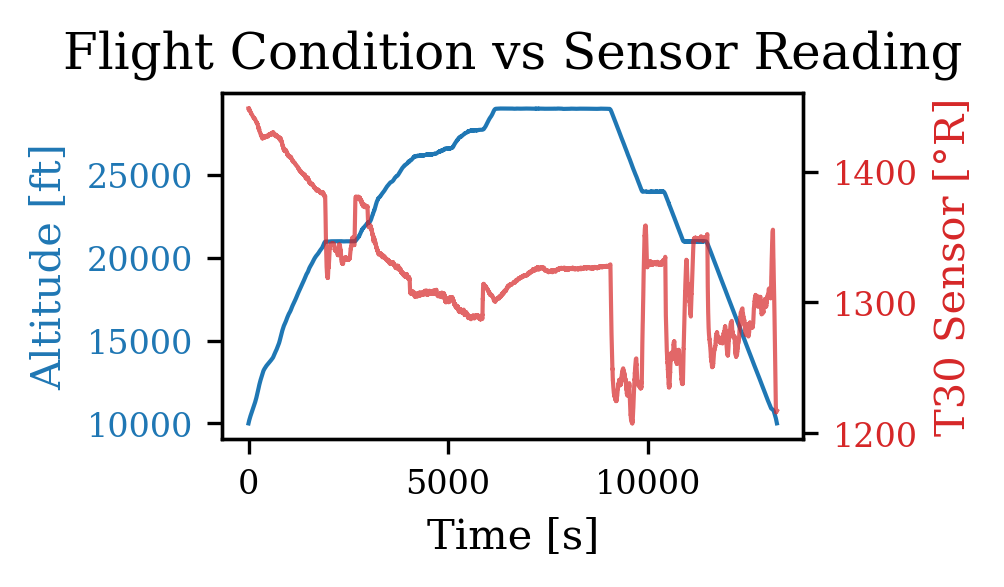

In [8]:
try:
    df_flight = df_completo[(df_completo['unit'] == 2.0) & (df_completo['cycle'] == 10.0)].reset_index(drop=True)
    
    fig, ax1 = plt.subplots(figsize=(2.5, 1.5))

    color = 'tab:blue'
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Altitude [ft]', color=color)
    ax1.plot(df_flight.index, df_flight['alt'], color=color, linewidth=1)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('T30 Sensor [°R]', color=color)  
    # Pegando um sensor de exemplo (T30)
    ax2.plot(df_flight.index, df_flight['T30'], color=color, linewidth=1, alpha=0.7)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Flight Condition vs Sensor Reading')
    plt.show()
except NameError:
    pass

### 4.4. Variação de Sobrevida entre Unidades (Fleet Analysis)
- **O que é:** Plotar a curva de degradação do RUL (ou sensores vitais) ao longo dos ciclos para várias unidades distintas no mesmo gráfico.
- **Motivação:** Evidenciar que não há um "tempo fixo" de quebra.
- **Impacto no Artigo:** Comprova que os dados têm alta variação comportamental inter-unidade. Uma unidade pode falhar no ciclo 60, e outra no ciclo 85. Isso destaca o quão robusto o modelo treinado (a Rede Neural) tem que ser para generalizar as predições para toda a frota.

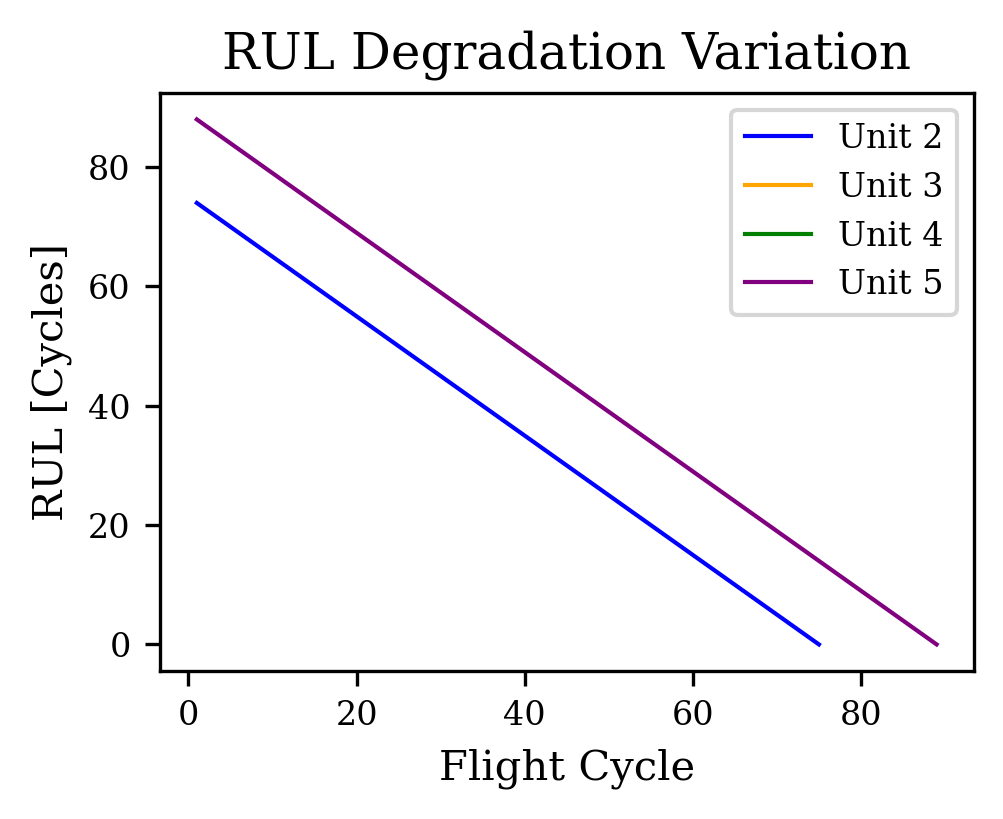

In [9]:
try:
    plt.figure(figsize=(3.5, 2.5))
    
    unidades_plot = [2.0, 3.0, 4.0, 5.0]
    colors = ['blue', 'orange', 'green', 'purple']
    
    for u, c in zip(unidades_plot, colors):
        df_u = df_completo[df_completo['unit'] == u].drop_duplicates(subset=['cycle'])
        plt.plot(df_u['cycle'], df_u['RUL'], color=c, label=f'Unit {int(u)}', linewidth=1)
        
    plt.xlabel('Flight Cycle')
    plt.ylabel('RUL [Cycles]')
    plt.title('RUL Degradation Variation')
    plt.legend()
    plt.show()
except NameError:
    pass